In [1]:
import json, random
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

jsonl_path = "/glob/g01-cache/pf/Yushuo/vjepa201/data/embodiedscan_train.jsonl"
rows = [json.loads(l) for l in open(jsonl_path)]
print(f"Total rows: {len(rows)}")

Total rows: 95378


## random select an item to illustrate

Query: select the curtain that is close to the dresser
Images: 8
Boxes: [None, [0.0, 0.0, 214.2313278879028, 518.0], [0.0, 0.0, 15.763374678951195, 518.0], None, None, None, [0.0, 0.0, 27.24858503507994, 518.0], None]


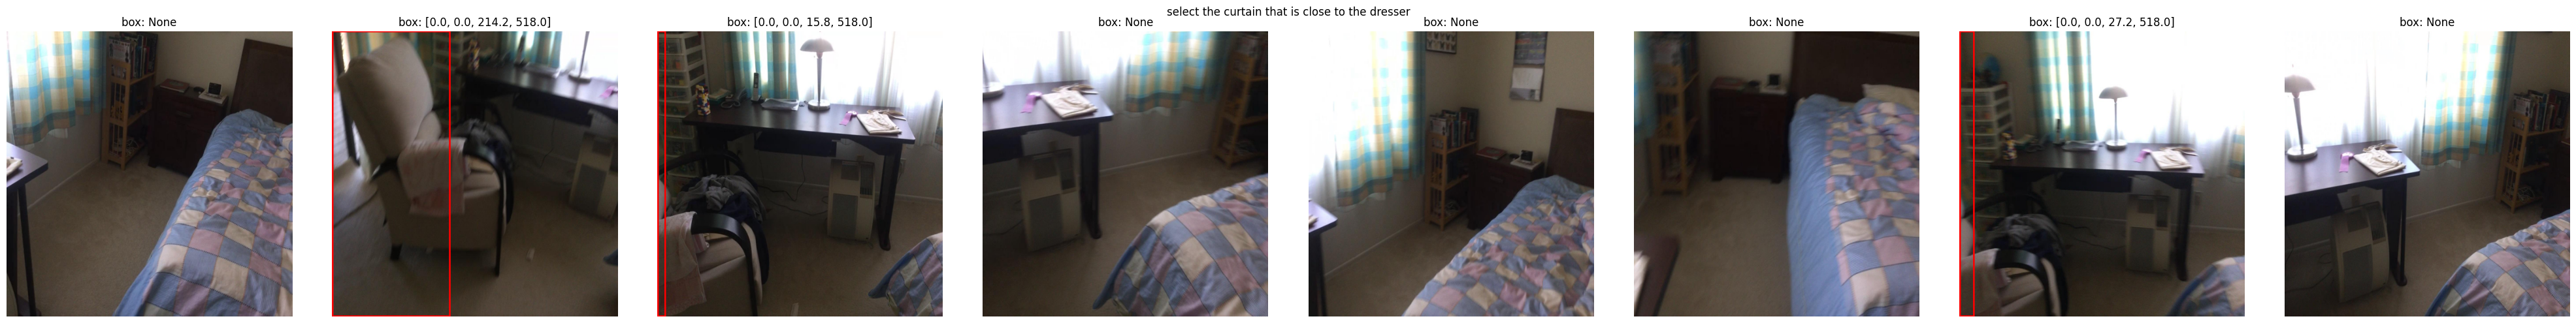

In [2]:
row = random.choice(rows)
print("Query:", row["query"])
print("Images:", len(row["images"]))
print("Boxes:", row["boxes"])

fig, axes = plt.subplots(1, len(row["images"]), figsize=(5*len(row["images"]), 5))
if len(row["images"]) == 1:
      axes = [axes]

for ax, img_path, box in zip(axes, row["images"], row["boxes"]):
      img = Image.open(img_path).convert("RGB")
      img = img.resize((518, 518))
      draw = ImageDraw.Draw(img)
      if box is not None:
          x1, y1, x2, y2 = box
          draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
      ax.imshow(img)
      ax.set_title("box: " + (str([round(v,1) for v in box]) if box else "None"))
      ax.axis("off")

plt.suptitle(row["query"], fontsize=12)
plt.tight_layout()
plt.show()

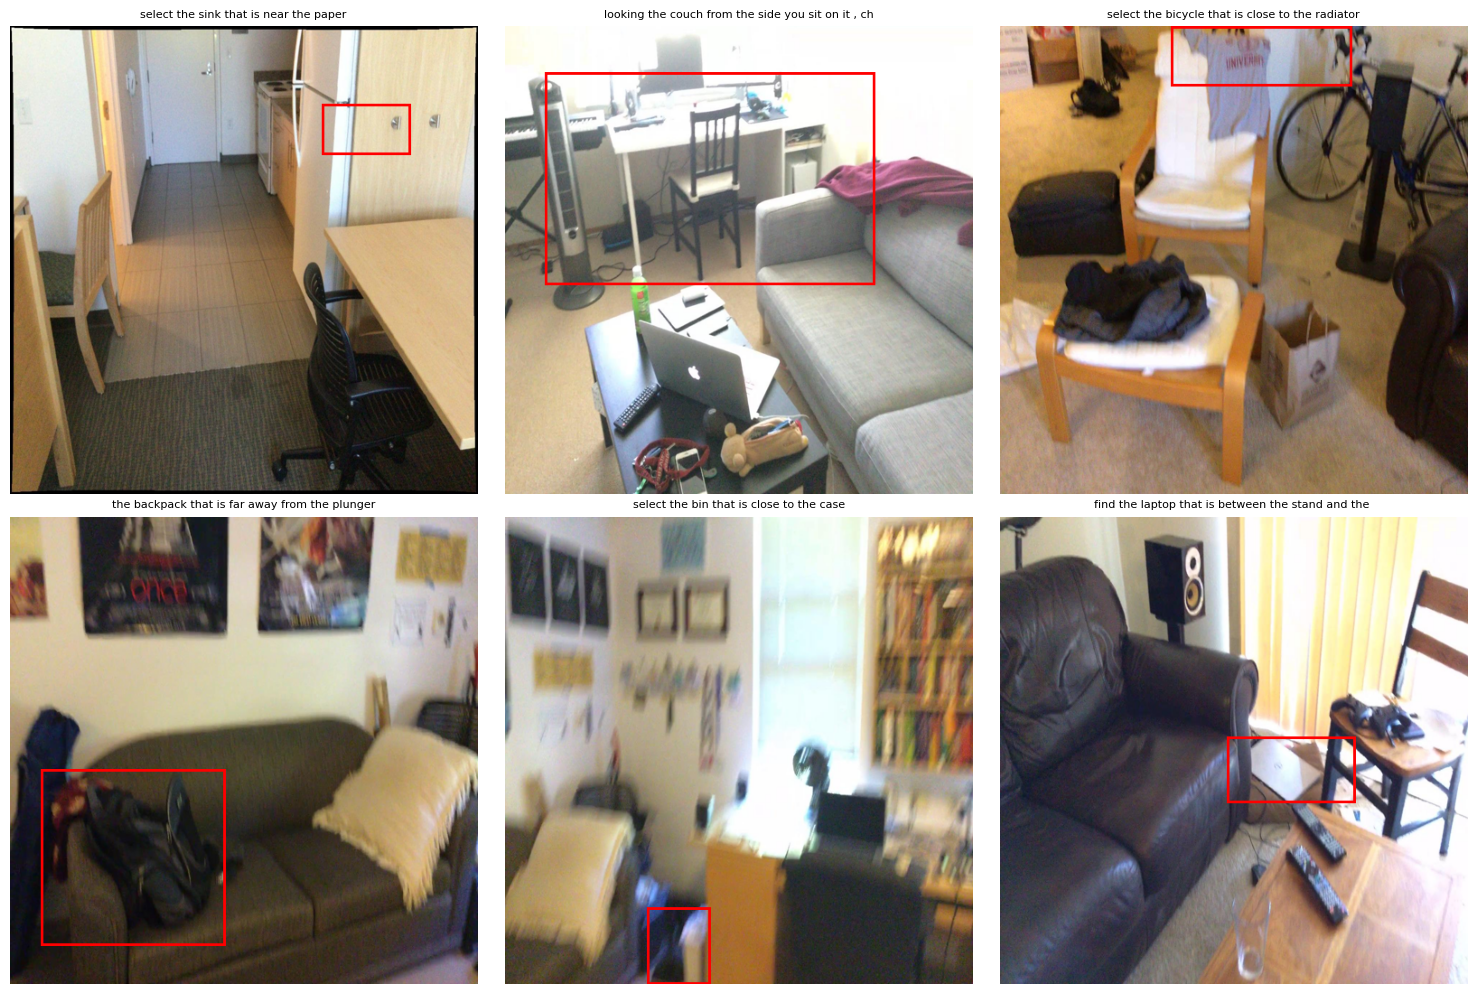

In [3]:
samples = random.sample(rows, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, row in zip(axes.flat, samples):
      for img_path, box in zip(row["images"], row["boxes"]):
          if box is not None:
              img = Image.open(img_path).convert("RGB").resize((518, 518))
              draw = ImageDraw.Draw(img)
              draw.rectangle(box, outline="red", width=3)
              ax.imshow(img)
              ax.set_title(row["query"][:50], fontsize=8)
              ax.axis("off")
              break

plt.tight_layout()
plt.show()

In [4]:
## check if there is some 2d boxes
import json
entries =json.load(open('/glob/g01-cache/pf/Yushuo/vjepa201/source_data/embodiedscan/embodiedscan/embodiedscan_train_vg.json'))
print(entries[0].keys())
print(entries[0])

dict_keys(['scan_id', 'target_id', 'distractor_ids', 'text', 'target', 'anchors', 'anchor_ids', 'tokens_positive'])
{'scan_id': 'scannet/scene0191_00', 'target_id': 5, 'distractor_ids': [6], 'text': 'the board that is beside the door', 'target': 'board', 'anchors': ['door'], 'anchor_ids': [3], 'tokens_positive': [[4, 9]]}
